**Kurulum ve import**:
Gerekli kütüphaneler içe aktarılır ve device ayarlanır (cuda/cpu).

In [1]:
# Gerekirse kütüphaneleri yüklemek için bu satırı çalıştırın:
# !pip install torch numpy pandas matplotlib scikit-learn joblib gradio

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import gradio as gr
import io
from PIL import Image

# Cihaz konfigürasyonu (GPU varsa kullanalım, yoksa CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sistem şu cihaz üzerinde çalışacak: {device}")

C:\Users\halit\IdeaProjects\Hack\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sistem şu cihaz üzerinde çalışacak: cpu


**Veri yükleme ve ön işleme**

* PJME_hourly.csv okunur
* Datetime index yapılır ve zaman sıralaması garanti edilir
* PJME_MW değerleri alınır
* Modelin daha stabil öğrenmesi için MinMaxScaler ile 0–1 aralığına normalize edilir

In [2]:
# Veri setini yükleme
try:
    df = pd.read_csv('PJME_hourly.csv')
    print("Veri seti başarıyla yüklendi.")
except FileNotFoundError:
    print("HATA: 'PJME_hourly.csv' dosyası bulunamadı. Lütfen dosyanın dizinde olduğundan emin olun.")

# Tarih formatını düzenleme ve index atama
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Sadece tüketim verisini alıyoruz
data = df['PJME_MW'].values.reshape(-1, 1)

# Veriyi 0-1 arasına sıkıştırma (Normalization)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Toplam veri noktası sayısı: {len(scaled_data)}")

Veri seti başarıyla yüklendi.
Toplam veri noktası sayısı: 145366


**Zaman serisini modele uygun forma çevirme**

LSTM’e “son 24 saat → bir sonraki saat” mantığını öğretmek için veri şöyle hazırlanır:
* seq_length = 24
* Her örnek: 24 saatlik pencere (X)
* Etiket: 25. saat (y)

Sonra veri %80 train / %20 test diye ayrılır.

In [3]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(scaled_data, seq_length)

# Tensor dönüşümleri
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)

# Eğitim ve Test setlerine ayırma (%80 Eğitim, %20 Test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: torch.Size([116273, 24, 1])
Test seti boyutu: torch.Size([29069, 24, 1])


**Model mimarisi**

Modelin özeti:
* 2 katmanlı LSTM (num_layers=2)
* hidden_size=64
* Dropout (dropout=0.2) ile ezberin azaltılması
* Son adım çıktısı alınıp Linear katmanla 1 değere (tahmin) çevrilmesi

In [4]:
class AdvancedLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(AdvancedLSTM, self).__init__()
        # batch_first=True: Giriş formatı (Batch, Seq, Feature) olur
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # LSTM katmanı
        out, _ = self.lstm(x)
        # Sadece son zaman adımının çıktısını alıyoruz
        out = out[:, -1, :]
        # Tam bağlantılı katman (Linear)
        out = self.fc(out)
        return out

model = AdvancedLSTM(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(device)
print(model)

AdvancedLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


**Model eğitimi**

* Kayıp fonksiyonu: MSELoss
* Optimizasyon: Adam (lr=0.001)
* Epoch sayısı: 50
* Eğitim sonunda:
    * Model ağırlıkları: advanced_lstm_model.pth
    * Ölçekleyici: scaler.gz
    * Eğitim loss grafiği çizilir

--- PROFESYONEL MODEL EĞİTİMİ BAŞLIYOR ---
Epoch [5/50] - Loss: 0.039519
Epoch [10/50] - Loss: 0.019920
Epoch [15/50] - Loss: 0.020640
Epoch [20/50] - Loss: 0.017720
Epoch [25/50] - Loss: 0.018754
Epoch [30/50] - Loss: 0.017367
Epoch [35/50] - Loss: 0.016706
Epoch [40/50] - Loss: 0.016728
Epoch [45/50] - Loss: 0.016045
Epoch [50/50] - Loss: 0.015750

Eğitim tamamlandı. Model ve Scaler diske kaydedildi.


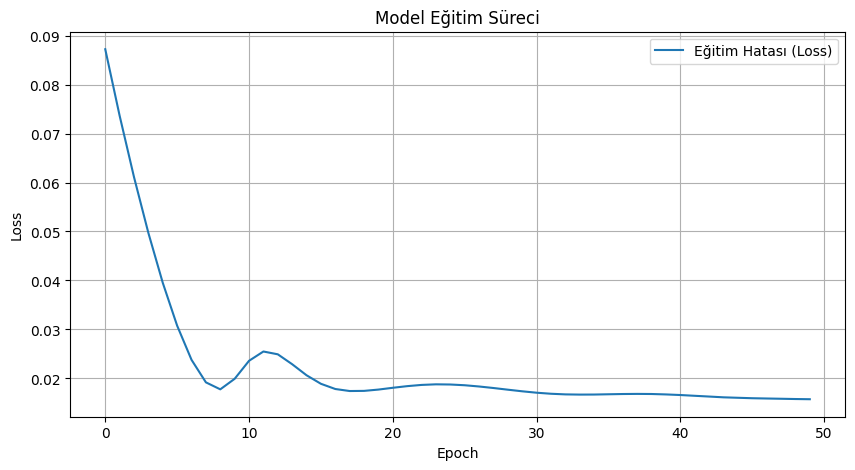

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
loss_history = []

print("--- PROFESYONEL MODEL EĞİTİMİ BAŞLIYOR ---")
model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.6f}")

# Modeli ve Scaler'ı kaydediyoruz
torch.save(model.state_dict(), "advanced_lstm_model.pth")
joblib.dump(scaler, "scaler.gz")
print("\nEğitim tamamlandı. Model ve Scaler diske kaydedildi.")

# Loss Grafiği
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Eğitim Hatası (Loss)')
plt.title('Model Eğitim Süreci')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Performans değerlendirme**

Test setinde:
* RMSE (kök ortalama kare hata)
* MAE (ortalama mutlak hata)
* R² (açıklanan varyans)

Ayrıca “ilk 200 test örneği” için:
* Gerçek tüketim vs model tahmini grafiği çizilir


--- MODEL PERFORMANS RAPORU ---
RMSE (Kök Ortalama Kare Hata): 6012.69 MW
MAE (Ortalama Mutlak Hata)   : 4797.82 MW
R² Score (Başarı Oranı)      : 0.1415
-------------------------------


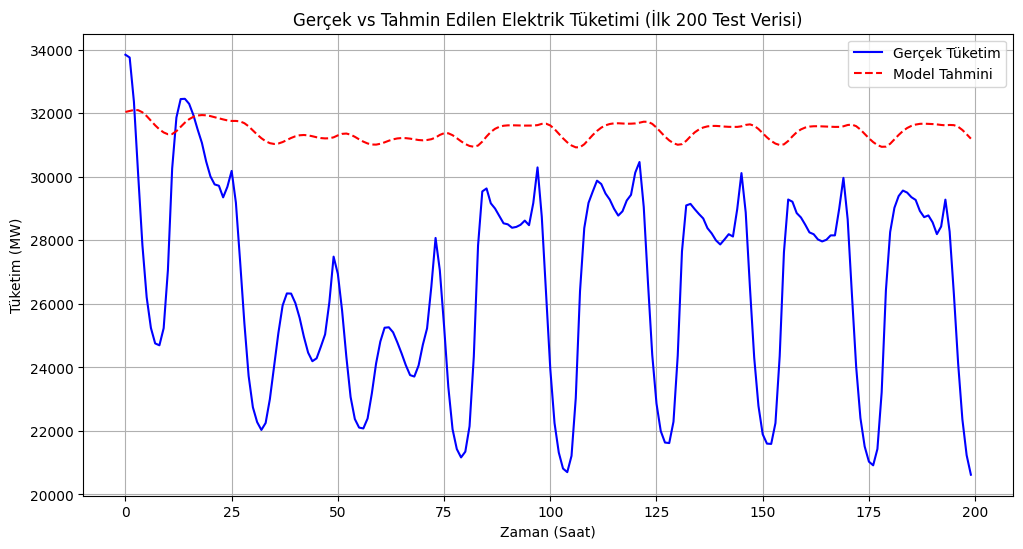

In [6]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test)
    # Tahminleri ve gerçek verileri orijinal ölçeğe (MW cinsine) geri döndürüyoruz
    test_preds_actual = scaler.inverse_transform(test_preds.cpu().numpy())
    y_test_actual = scaler.inverse_transform(y_test.cpu().numpy())

rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds_actual))
mae = mean_absolute_error(y_test_actual, test_preds_actual)
r2 = r2_score(y_test_actual, test_preds_actual)

print("\n--- MODEL PERFORMANS RAPORU ---")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse:.2f} MW")
print(f"MAE (Ortalama Mutlak Hata)   : {mae:.2f} MW")
print(f"R² Score (Başarı Oranı)      : {r2:.4f}")
print("-------------------------------")

# Tahmin Grafiği (İlk 200 veri)
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual[:200], label='Gerçek Tüketim', color='blue')
plt.plot(test_preds_actual[:200], label='Model Tahmini', color='red', linestyle='--')
plt.title('Gerçek vs Tahmin Edilen Elektrik Tüketimi (İlk 200 Test Verisi)')
plt.xlabel('Zaman (Saat)')
plt.ylabel('Tüketim (MW)')
plt.legend()
plt.grid(True)
plt.show()

**Gradio arayüz**

Gradio ile bir demo ekranı hazırlanır:
* Kullanıcıdan virgülle ayrılmış tüketim değerleri alınır
* Model tahmini hesaplanır
* Son 24 saat + tahmin noktası grafikte gösterilir
* Arayüz, çalıştırılınca bir link üretir (demo.launch(share=True))

In [7]:
# Gerekli CSS Stilleri
custom_css = """
.gradio-container { font-family: 'Roboto', sans-serif; }
#header-markdown { text-align: center; margin-bottom: 20px; }
#header-markdown h1 {
    background: linear-gradient(90deg, #3B82F6, #8B5CF6);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    font-size: 2.5em; font-weight: bold;
}
#predict-btn { background: linear-gradient(90deg, #2563EB, #4F46E5); color: white; }
"""

def analyze_energy(input_text):
    try:
        if not input_text: return "Veri Girilmedi", None, "Lütfen veri giriniz."

        # Girdi verisini işleme
        input_list = [float(x.strip()) for x in input_text.split(',')]

        # Eğer veri 24'ten azsa başını doldur, çoksa son 24'ü al
        if len(input_list) < 24:
            needed = 24 - len(input_list)
            input_list = [input_list[0]] * needed + input_list
        relevant_data = input_list[-24:]

        # Modele hazırlık
        input_array = np.array(relevant_data).reshape(-1, 1)
        scaled_input = scaler.transform(input_array)
        input_tensor = torch.tensor(scaled_input.reshape(1, 24, 1), dtype=torch.float32).to(device)

        # Tahmin
        with torch.no_grad():
            pred_scaled = model(input_tensor)
        pred_mw = scaler.inverse_transform(pred_scaled.cpu().numpy())[0][0]

        # Grafik oluşturma (Dark Mode Style)
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor('#111827')
        ax.set_facecolor('#1f2937')

        x_past = range(len(relevant_data))
        ax.plot(x_past, relevant_data, color='#00d4ff', marker='o', label='Son 24 Saat')
        ax.plot(24, pred_mw, color='#ff0055', marker='*', markersize=15, label='Tahmin')
        ax.plot([23, 24], [relevant_data[-1], pred_mw], color='#ff0055', linestyle='--', alpha=0.5)

        ax.set_title(f"Enerji Tüketim Analizi", color='white')
        ax.legend()

        # Grafiği resme çevirme
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor())
        buf.seek(0)
        img = Image.open(buf)
        plt.close(fig)

        return f"{pred_mw:.2f} MW", img, f"Analiz Başarılı! Öngörülen: {pred_mw:.2f} MW"

    except Exception as e:
        return "Hata", None, f"Sistem Hatası: {str(e)}"

# Örnek Veri
example_data = "30000, 31200, 32500, 33100, 34500, 35000, 36200, 35800, 34500, 33200, 32100, 31500, 30200, 29500, 28800, 28500, 29200, 30500, 31800, 32900, 33500, 34800, 35500, 36100"

# Arayüz Yapısı
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔋 Akıllı Şebeke Enerji Tahmini", elem_id="header-markdown")

    with gr.Row():
        with gr.Column():
            input_box = gr.Textbox(lines=3, value=example_data, label="Son 24 Saat Tüketim Verileri")
            analyze_btn = gr.Button("Analiz Et", elem_id="predict-btn")
            status_box = gr.Textbox(label="Sistem Durumu", interactive=False)
        with gr.Column():
            result_box = gr.Textbox(label="Gelecek Saat Tahmini (MW)", text_align="center")
            plot_box = gr.Image(label="Trend Analizi", type="pil")

    gr.Markdown("<div style='text-align: center; margin-top: 10px;'>BMT Project - Halit Ersoy</div>")

    analyze_btn.click(analyze_energy, inputs=[input_box], outputs=[result_box, plot_box, status_box])

# Başlat
demo.launch(share=True)

C:\Users\halit\AppData\Local\Temp\ipykernel_74816\2170529920.py:66: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
